 Copyright © Sorbonne University.

 This source code is licensed under the MIT license found in the
 LICENSE file in the root directory of this source tree.

# PLDAC - RL TABULAIRE


In this notebook, we will code a naive actor-critic algorithm in the tabular case using q-tables instead of the value function v.


## Install libraries

Installs the necessary Python and system libraries

In [1]:
try:
    from easypip import easyimport
except ModuleNotFoundError:
    from subprocess import run
    assert run(["pip", "install", "easypip"]).returncode == 0, "Could not install easypip"
    from easypip import easyimport

easyimport("swig")
easyimport("bbrl_utils").setup(maze_mdp=True)

import os
from pathlib import Path
from typing import List, Tuple

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from bbrl_gymnasium.envs.maze_mdp import MazeMDPEnv
from bbrl_utils.notebook import tqdm
from mazemdp.mdp import Mdp
from mazemdp.toolbox import egreedy, egreedy_loc, sample_categorical, softmax
from mazemdp import random_policy
import bbrl_gymnasium  # noqa: F401

Matplotlib backend: module://matplotlib_inline.backend_inline


/home/sigaud/.local/lib/python3.9/site-packages/bbrl_utils/notebook.py:46: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm  # noqa: F401


In [2]:
# matplotlib.use("TkAgg")

from functools import partial
!pip install optuna
import optuna
import yaml
import hydra
from omegaconf import OmegaConf, DictConfig

import seaborn as sns
sns.set_theme()
import logging
optuna.logging.set_verbosity(optuna.logging.WARNING)


# Step 1: Updating the naive Actor-critic algorithm with Q-values

We consider the naive actor-critic algorithm with a categorical policy.  
The algorithm learns a critic with the standard temporal difference mechanism  
using a learning rate \(\alpha_{critic}\).

We consider a **Q-value-based critic** \(Q(s, a)\) instead of a value-based critic \(V(s)\), which allows the algorithm to estimate the value of taking action \(a\) from state \(s\).  


---

## Critic Update Rules

We implement four different update rules for the Q-values:

1. **SARSA Update Rule**  
   $Q(s_t, a_t) ← Q(s_t, a_t) + alpha-critic [r_{t+1} + \gamma Q(s_{t+1}, a_{t+1}) - Q(s_t, a_t)]$

   This rule follows the **on-policy** approach, where the next action is drawn according to the policy.  

2. **Q-learning Update Rule**  
   $Q(s_t, a_t) ← Q(s_t, a_t) + alpha-critic [r_{t+1} + \gamma max_a Q(s_{t+1}, a) - max_a Q(s_t, a)]$
   
   This rule follows the **off-policy** approach, where the best possible action is chosen greedily.  

3. **"Mean" SARSA Update Rule**  
   $Q(s_t, a_t) ← Q(s_t, a_t) + alpha-critic [r_{t+1} + \gamma max_a Q(s_{t+1}, a) - \Sigma_a \pi(a|s_t)  Q(s_t, a)]$
   
   This rule leverages the **expected value** of the Q-function over all actions, weighted by the current policy.  

4. **Fourth Update Rule**  
   $Q(s_t, a_t) ← Q(s_t, a_t) + alpha-critic [r_{t+1} + \gamma max_a Q(s_{t+1}, a) - Q(s_t, a_t)]$  
   This rule uses a one-step update towards the maximum Q-value of the next state.  
   
   

---

## Actor Update

To update the actor, the general idea is the same, using the temporal difference error with another learning rate $\alpha_{actor}$.

However, naively applying the same learning rule would not ensure that the probabilities of all actions in a state sum to 1.
Besides, when the temporal difference error $\delta_t$ is negative, it may happen that the probability of an action gets negative or null, which raises an issue when applying renormalization.

So, instead of applying the naive rule, we apply the following one:
$$
\pi_{temp}(a_t|s_t) =  \begin{cases}
\pi^{(i)}(a_t|s_t) + \alpha_{actor} \delta_t & \mathrm{if } \pi^{(i)}(a_t|s_t) + \alpha_{actor} \delta_t > 10^{-8}\\
10^{-8} & \mathrm{otherwise.} \\
\end{cases}
$$

Then we can apply renormalization so that the probabilities of actions still sum to 1, with
$$
\forall a, \pi^{(i+1)}(a|s_t) = \frac{\pi_{temp}^{(i+1)}(a|s_t)} {\sum_{a'} \pi_{temp}^{(i+1)}(a'|s_t)}
$$ with
$$
\pi_{temp}^{(i+1)}(a|s_t) =  \begin{cases}
\pi_{temp}(a|s_t) & \mathrm{if } a = a_t\\
\pi^{(i)}(a|s_t) & \mathrm{otherwise.} \\
\end{cases}
$$

---

## Implementation:

We provide a Python implementation of the naive actor-critic algorithm with Q-values using the four update rules.  


---


In [3]:
def renormalize(
    mdp: MazeMDPEnv,
    policy: np.array,
    state: np.array,
) -> None:
    """
    Renormalize the probability of actions so that the sum of probabilities over actions is always 1.
    We made sure in the calling function that the probabilities of action never get negative when they are decreased.
    :param mdp: the mdp the agent is working in (to get the number of actions)
    :param policy: the current policy, before normalization
    :param state: the state where the actions need to be renormalized
    :return: nothing
    """

    policy[state] = policy[state] / np.sum(policy[state])


In [4]:
import numpy as np

def perform_episode(
    policy: np.array,
    q: np.array,
    alpha_critic: float,
    alpha_actor: float,
    update_type: int,
    render: bool = True,
    stagnation_threshold: float = 0.1,
    max_no_improve: int = 10
) -> int:
    """
    Perform an episode on the given mdp with the given policy using Q-values.
    :param update_type: int indicating the chosen update rule (1, 2, 3, 4).
    :return: the number of steps before it stops
    """
    state, _ = mdp.reset(uniform=True)  # reinit env, get initial state
    terminated = False
    truncated = False
    steps = 0
    episode_rewards = []
    last_avg_reward = None
    no_improvement_count = 0

    while not (terminated or truncated):
        # if steps % 10000 == 0:
            # print(f"Step: {steps}, State: {state}, Terminated: {terminated}, Truncated: {truncated}")

        action = sample_categorical(policy[state])  # draw action from the policy
        next_state, reward, terminated, truncated, _ = mdp.step(action)

        # max Q-value for the next state
        max_q_next = np.max(q[next_state])

        # next action according to the current policy (for SARSA)
        next_action = sample_categorical(policy[next_state])

        # TD error (delta) based on the selected update type
        if update_type == 1:
            # 1: SARSA update rule
            delta = reward + mdp.gamma * q[next_state, next_action] * (1 - terminated) - q[state, action]
            # print(f"delta ({update_type}) - State: {state}, Action: {action}, Delta: {delta}")

        elif update_type == 2:
            # 2: Q-learning update rule
            delta = reward + mdp.gamma * max_q_next * (1 - terminated) - np.max(q[state])
            # print(f"delta ({update_type}) - State: {state}, Action: {action}, Delta: {delta}")

        elif update_type == 3:
            # 3: MEAN SARSA update rule
            sum = np.sum(policy[state] * q[state])
            delta = reward + mdp.gamma * max_q_next * (1 - terminated) - sum
            # print(f"delta ({update_type}) - State: {state}, Action: {action}, Delta: {delta}")
            # print(f"Perform Episode - Update Type 3 - State: {state}, Sum Q: {sum}, Delta: {delta}")

        elif update_type == 4:
            # 4: Fourth update rule
            delta = reward + mdp.gamma * max_q_next * (1 - terminated) - q[state, action]
            # print(f"delta ({update_type}) - State: {state}, Action: {action}, Delta: {delta}")

        else:
            raise ValueError("Invalid update type")

        # Update the Q-value with the delta
        q[state, action] += alpha_critic * delta

        # Update the policy with the new Q-values using the softmax function
        policy_temp = policy[state, action] + alpha_actor * delta
        policy[state, action] = max(policy_temp, 1e-8)

        renormalize(mdp, policy, state)
        # print(f"Policy sum for state {state}: {np.sum(policy[state])}")
        assert np.isclose(np.sum(policy[state]), 1.0), "Policy is not properly normalized!"

        # Move to the next state
        state = next_state
        steps += 1

        # Track the reward for averaging
        episode_rewards.append(reward)

        # Calculate the average reward over the last N steps
        avg_reward = np.mean(episode_rewards[-1000:])

        # Detect stagnation based on the reward change
        if last_avg_reward is not None and abs(avg_reward - last_avg_reward) < stagnation_threshold:
            no_improvement_count += 1
        else:
            no_improvement_count = 0

        last_avg_reward = avg_reward

        # Stop if stagnation persists for a number of episodes
        if no_improvement_count >= max_no_improve:
            # print(f"Stagnation detected after {steps} steps. Avg reward: {avg_reward}")
            return np.linalg.norm(q), steps

        value_norm = np.linalg.norm(q)
        # print(f"Norm of Q-values: {value_norm}")

    return np.linalg.norm(q), steps


Here comes the main actor-critic function. It should take the shown parameters as input and output a list of value norms and a list of number of steps,
corresponding to the evolution of these quantities through learning

In [5]:
def actor_critic_q(
    nb_episodes: int,
    alpha_critic: float,
    alpha_actor: float,
    update_type: int,
    render: bool = True,
) -> np.array:
    """
    Perform actor-critic training over a number of episodes with Q-values.
    :param update_type: int indicating the chosen update rule (1, 2, 3, 4).
    :return: a list of norm of Q values and a list of number of steps of episodes
    """
    # Initialize Q-values to zero
    q = np.zeros((env.nb_states, env.action_space.n)) # MAIN CHANGES FROM PREVIOUSLY

    # Initialize uniform policy
    policy = np.ones((env.nb_states, env.action_space.n)) / env.action_space.n

    # Store the number of steps and norms
    nb_steps = []
    value_norms = []

    for ep in range(nb_episodes):
        # print(f" Actor_critic_q function - looping Episode {ep + 1}/{nb_episodes}")
        value_norm, steps = perform_episode(policy, q, alpha_critic, alpha_actor, update_type, render)
        value_norms.append(value_norm)
        nb_steps.append(steps)

    return value_norms, nb_steps, policy, q

## Provide a plot function

Your plot function should show the evolution through time of number of steps the agent takes to find the reward in the maze.
If your algorithm works, this number of steps should decrease through time.

Your plot function should also show a mean and a standard deviation (or some more advanced statistics) over a collection of learning runs.
Make sure that your figure complies with [The figure checklist](https://master-dac.isir.upmc.fr/The_figure_checklist.pdf).

## Separating plot_steps into 2 functions

Quand on fait .unwrapped, tu retires tous les wrappers de Gymnasium, notamment :

Le wrapper TimeLimit, qui force la fin de l’épisode après un certain nombre de pas.

Le wrapper de troncature (truncated=True) qui indique que l’agent a dépassé l’horizon maximal (max_episode_steps).

👉 Conséquence :

Ton agent peut continuer à tourner indéfiniment sans atteindre un état terminal ou "truncated", ce qui fait que la boucle while not (terminated or truncated) ne se termine jamais.

In [6]:
import time
from datetime import timedelta

def make_mdp(cfg):
    mdp = gym.make(cfg.mdp.name, kwargs={"width": cfg.mdp.width, "height": cfg.mdp.height, "ratio": cfg.mdp.ratio}, render_mode=cfg.mdp.render_mode)
    env = mdp.unwrapped
    return mdp , env

In [7]:
def run_experiment(cfg, nb_runs):
    """ Exécute l'algorithme Actor-Critic et retourne les résultats. """
    update_names = ["SARSA", "Q-learning", "Mean SARSA", "Fourth Rule"]
    all_results = []
    summary = []

    for update_type in range(1, 5):
        all_steps = []

        for run in range(nb_runs):
            _, nb_steps, _, _ = actor_critic_q(cfg.nb_episodes, cfg.alpha_critic, cfg.alpha_actor, update_type, cfg.render)
            all_steps.append(nb_steps)

        # Convertir en numpy arrays pour le calcul des statistiques
        all_steps = np.array(all_steps)
        mean_steps = np.mean(all_steps, axis=0)
        std_steps = np.std(all_steps, axis=0)

        all_results.append((update_names[update_type - 1], mean_steps, std_steps))
        summary.append([update_names[update_type - 1], np.mean(mean_steps), np.std(mean_steps)])

    return all_results, summary

In [8]:
# ========== Fonction pour le tracé des résultats ==========
def plot_results(all_results, cfg):
    """ Affiche les courbes de performance en fonction des mises à jour et enregistre les plots. """

    # Créer le dossier "plots" si nécessaire
    if not os.path.exists('plots'):
        os.makedirs('plots')

    # Création du plot
    plt.figure(figsize=(12, 8))
    plt.title(f"Actor-Critic Performance - Comparison of Update Rules (gamma={cfg.mdp.gamma})")
    plt.xlabel("Episode")
    plt.ylabel("Number of Steps")
    plt.grid(True, linestyle="--", alpha=0.6)

    for name, mean_steps, std_steps in all_results:
        plt.plot(mean_steps, label=f"{name} - Mean Steps")
        plt.fill_between(range(cfg.nb_episodes), mean_steps - std_steps, mean_steps + std_steps, alpha=0.2)

    plt.legend(loc="upper right")

    # Générer un nom de fichier basé sur les paramètres
    plot_filename = f"actor_critic_comparison_gamma_{env.gamma}_alpha_critic_{cfg.alpha_critic}_alpha_actor_{cfg.alpha_actor}.pdf"
    plot_filepath = os.path.join('plots', plot_filename)

    # Sauvegarder le plot dans le dossier "plots"
    plt.savefig(plot_filepath)
    print(f"Plot saved to {plot_filepath}")

    # Afficher le plot
    plt.show()



Test avec alpha_critic=0.8, alpha_actor=0.5 et gamma=0.9


/home/sigaud/.local/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.gamma to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.gamma` for environment variables or `env.get_wrapper_attr('gamma')` that will search the reminding wrappers.
  logger.warn(


Temps d'exécution pour 100 runs avec gamma = 0.9 : 0:00:32.340661


Résumé des résultats :
    Update Rule  Mean Steps  Standard Deviation
0        SARSA     10.8586            0.098773
1   Q-learning     10.8423            0.096818
2   Mean SARSA     10.8368            0.110443
3  Fourth Rule     10.8326            0.114321
Plot saved to plots/actor_critic_comparison_gamma_0.9_alpha_critic_0.8_alpha_actor_0.5.pdf


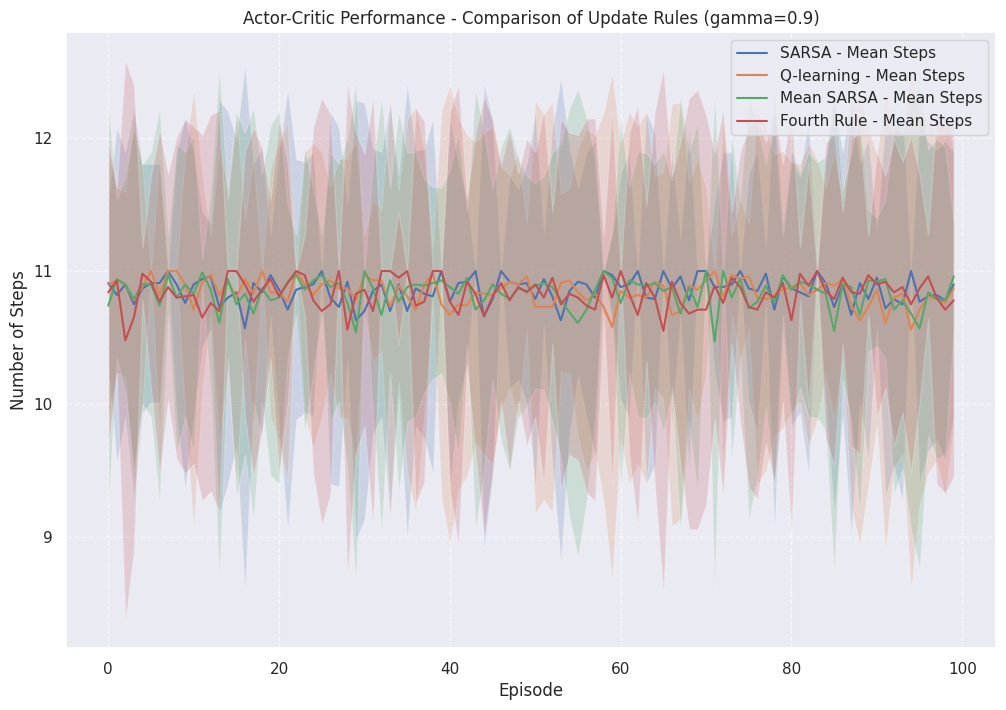



Test avec alpha_critic=0.8, alpha_actor=0.5 et gamma=0.95


/home/sigaud/.local/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.gamma to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.gamma` for environment variables or `env.get_wrapper_attr('gamma')` that will search the reminding wrappers.
  logger.warn(


Temps d'exécution pour 100 runs avec gamma = 0.95 : 0:00:32.317938


Résumé des résultats :
    Update Rule  Mean Steps  Standard Deviation
0        SARSA     10.8445            0.112226
1   Q-learning     10.8382            0.108484
2   Mean SARSA     10.8345            0.112093
3  Fourth Rule     10.8369            0.101919
Plot saved to plots/actor_critic_comparison_gamma_0.9_alpha_critic_0.8_alpha_actor_0.5.pdf


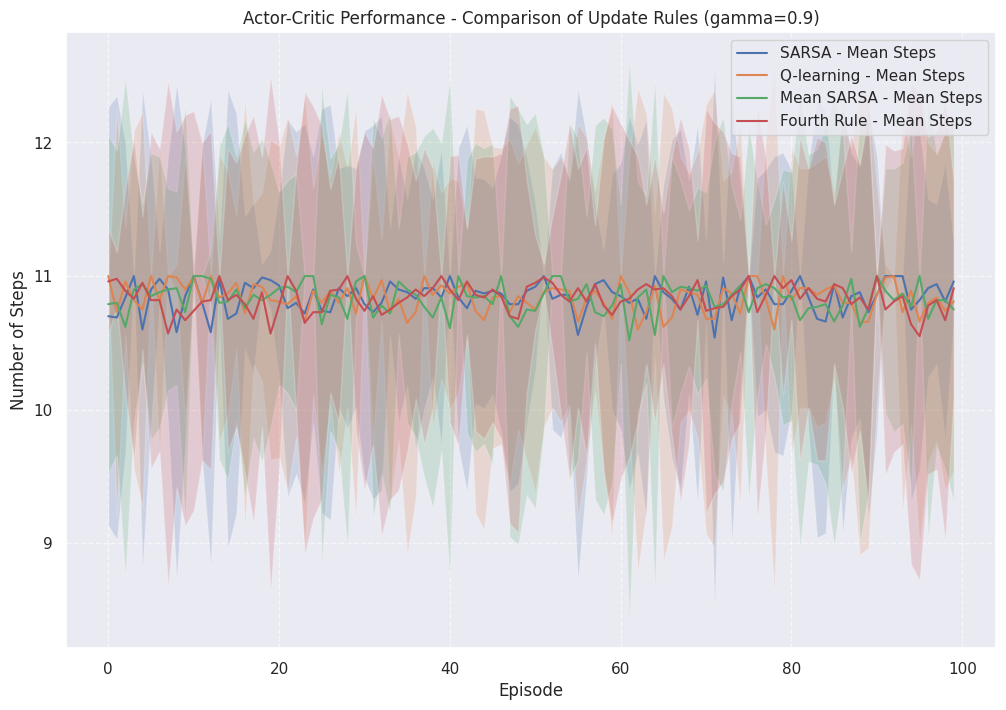



Test avec alpha_critic=0.8, alpha_actor=0.5 et gamma=0.99


/home/sigaud/.local/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.gamma to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.gamma` for environment variables or `env.get_wrapper_attr('gamma')` that will search the reminding wrappers.
  logger.warn(


In [ ]:
# ========== Exécution des tests sur plusieurs configurations ==========
# les taux d'apprentissages
hyperparameter_tests = [
    {"alpha_critic": 0.8, "alpha_actor": 0.5},  # Critic fort
    {"alpha_critic": 0.5, "alpha_actor": 0.8},  # Actor fort
]

ac_params = {
    "save_curves": False,
    "save_heatmap": True,
    "mdp": {
            "name": "MazeMDP-v0",
            "width": 15,
            "height": 15,
            "ratio": 0.2,
            "render_mode": "rgb_array",
            "gamma": 0.9,
        },
    "log_dir": "./tmp",
    "video_dir": "./tmp/videos",
    "nb_episodes": 100,
    "render": False,
    "nb_repeats": 5,
}
cfg = OmegaConf.create(ac_params)
mdp, env = make_mdp(cfg)  # Créer un nouvel environnement avec les paramètres actuels
N = 100  # Nombre de runs
gammas = [0.9, 0.95, 0.99]  # Test sur différentes valeurs de gamma

for params in hyperparameter_tests:
    for gamma in gammas:
        print(f"\n\nTest avec alpha_critic={params['alpha_critic']}, alpha_actor={params['alpha_actor']} et gamma={gamma}")
        
        cfg.gamma = gamma
        cfg.alpha_critic = params["alpha_critic"]
        cfg.alpha_actor = params["alpha_actor"]
        # Lancer le test et mesurer le temps d'exécution
        start_time = time.time()
        all_results, summary = run_experiment(cfg, N)
        end_time = time.time()

        elapsed_time = timedelta(seconds=(end_time - start_time))
        print(f"Temps d'exécution pour {N} runs avec gamma = {gamma} : {elapsed_time}\n")

        # Affichage des résultats
        summary_df = pd.DataFrame(summary, columns=["Update Rule", "Mean Steps", "Standard Deviation"])
        print("\nRésumé des résultats :\n", summary_df)

        plot_results(all_results, cfg)  # Tracer les résultats

## Actor-critic hyper-parameters

To represent the hyper-parameters of the experiments performed in this notebook, we suggest using the dictionary below.
This dictionary can be read using omegaconf.
Using it is not mandatory.
You can also change the value of hyper-parameters or environment parameters at will.

## Test your code

The code for testing what you did so far is provided below.

In [ ]:
# default given initially
ac_params = {
    "save_curves": False,
    "save_heatmap": True,
    "mdp": {
        "name": "MazeMDP-v0",
        "width": 15,
        "height": 15,
        "ratio": 0.0,
        "render_mode": "rgb_array",
        "gamma": 0.9
        },

    "log_dir": "./tmp",
    "video_dir": "./tmp/videos",

    "nb_episodes": 30,
    "render": False, # True, #
    "nb_repeats": 5,

    "alpha_critic": 0.5,
    "alpha_actor": 0.5,
    }

In [ ]:
from omegaconf import OmegaConf

cfg = OmegaConf.create(ac_params)

all_results, summary = run_experiment(cfg, nb_runs=cfg.nb_repeats)

plot_results(all_results, cfg)

### More tests...

In [ ]:
def run_static_tests(cfg, nb_runs=5):
    update_names = ["SARSA", "Q-learning", "Mean SARSA", "Fourth Rule"]
    all_static_results = []

    for update_type in range(1, 5):
        print(f"\nTesting {update_names[update_type - 1]}...\n")
        mdp, _ = make_mdp(cfg)
        q_tables = []
        total_rewards = []

        for _ in range(nb_runs):
            q = np.zeros((env.nb_states, env.action_space.n))
            policy = np.ones_like(q) / env.action_space.n

            rewards = []
            for ep in range(cfg.nb_episodes):
                _, steps = perform_episode(policy, q, cfg.alpha_critic, cfg.alpha_actor, update_type, render=False)
                rewards.append(steps)

            q_tables.append(q)
            total_rewards.append(rewards)

        all_static_results.append((update_names[update_type - 1], q_tables, total_rewards))

    return all_static_results

In [ ]:
from scipy.stats import ttest_ind

def compare_rewards_statistically(static_results):
    print("\n===== Statistical Reward Comparison =====\n")
    for i in range(len(static_results)):
        name_i, _, rewards_i = static_results[i]
        rewards_i = np.array(rewards_i).flatten()

        for j in range(i+1, len(static_results)):
            name_j, _, rewards_j = static_results[j]
            rewards_j = np.array(rewards_j).flatten()

            t_stat, p_val = ttest_ind(rewards_i, rewards_j)
            print(f"{name_i} vs {name_j} → p-value = {p_val:.4f} ", end='')
            if p_val < 0.05:
                print("✅ Significant difference")
            else:
                print("❌ Not significant")

In [ ]:
def plot_reward_curves(static_results, nb_episodes):
    plt.figure(figsize=(10, 6))
    plt.title("Reward comparison across Critic update rules")
    plt.xlabel("Episode")
    plt.ylabel("Average reward per episode")
    plt.grid(True)

    for name, _, rewards in static_results:
        rewards = np.array(rewards)
        mean_reward = rewards.mean(axis=0)
        std_reward = rewards.std(axis=0)
        plt.plot(mean_reward, label=f"{name}")
        plt.fill_between(range(nb_episodes), mean_reward - std_reward, mean_reward + std_reward, alpha=0.2)

    plt.legend()
    plt.show()


In [ ]:
cfg = OmegaConf.create(ac_params)
static_results = run_static_tests(cfg, nb_runs=5)

# Visualise les courbes
plot_reward_curves(static_results, cfg.nb_episodes)

# Statistiques
compare_rewards_statistically(static_results)


In [ ]:
def summarize_mean_rewards(static_results):
    summary = []

    for name, _, rewards in static_results:
        rewards = np.array(rewards)
        mean_reward = rewards.mean()
        std_reward = rewards.std()
        summary.append([name, mean_reward, std_reward])

    df_summary = pd.DataFrame(summary, columns=["Update Rule", "Mean Reward", "Std Reward"])
    df_summary = df_summary.sort_values(by="Mean Reward", ascending=False)

    print("\n===== Mean Rewards Summary =====")
    display(df_summary)

    return df_summary


In [ ]:
summary_df = summarize_mean_rewards(static_results)

In [ ]:
def plot_q_table_heatmaps(results):
    for name, q_tables, _ in results:
        avg_q = np.mean(q_tables, axis=0)
        plt.figure(figsize=(12, 6))
        plt.title(f"Q-table Heatmap - {name}")
        sns.heatmap(avg_q, cmap="viridis")
        plt.xlabel("Actions")
        plt.ylabel("States")
        plt.show()

In [ ]:
cfg = OmegaConf.create(ac_params)
static_results = run_static_tests(cfg, nb_runs=5)

mdp, _ = make_mdp(cfg)
plot_q_table_heatmaps(static_results)

In [ ]:
def plot_reward_curve_per_rule(rewards, update_rule_name, nb_episodes):
    plt.figure(figsize=(8, 5))
    plt.title(f"Reward per Episode - {update_rule_name}")
    plt.xlabel("Episode")
    plt.ylabel("Average Reward")
    plt.grid(True)

    rewards = np.array(rewards)
    mean_reward = rewards.mean(axis=0)
    std_reward = rewards.std(axis=0)

    plt.plot(mean_reward, label="Mean reward")
    plt.fill_between(range(nb_episodes), mean_reward - std_reward, mean_reward + std_reward, alpha=0.2)
    plt.legend()
    plt.show()


In [ ]:
for name, _, rewards in static_results:
    plot_reward_curve_per_rule(rewards, name, cfg.nb_episodes)

### Performance Curves - Steps per Episode for Each Critic Update Rule


In [ ]:
def plot_step_curve_per_rule(steps, update_rule_name, nb_episodes):
    plt.figure(figsize=(8, 5))
    plt.title(f"Steps per Episode - {update_rule_name}")
    plt.xlabel("Episode")
    plt.ylabel("Average Steps")
    plt.grid(True)

    steps = np.array(steps)
    mean_steps = steps.mean(axis=0)
    std_steps = steps.std(axis=0)

    plt.plot(mean_steps, label="Mean steps", color="orange")
    plt.fill_between(range(nb_episodes), mean_steps - std_steps, mean_steps + std_steps, alpha=0.2)
    plt.legend()
    plt.show()

In [ ]:
update_names = ["SARSA", "Q-learning", "Mean SARSA", "Fourth Rule"]
static_results = []

nb_episodes = ac_params["nb_episodes"]
alpha_critic = ac_params["alpha_critic"]
alpha_actor = ac_params["alpha_actor"]
nb_runs = ac_params["nb_repeats"]

for update_type in range(1, 5):
    all_rewards = []
    all_steps = []
    for run in range(nb_runs):
        rewards, steps, _, _ = actor_critic_q(nb_episodes, alpha_critic, alpha_actor, update_type, render=False)
        all_rewards.append(rewards)
        all_steps.append(steps)

    static_results.append((update_names[update_type - 1], all_steps, all_rewards))


In [ ]:
for name, steps, _ in static_results:
    plot_step_curve_per_rule(steps, name, ac_params["nb_episodes"])

# **Agreement Between Actor and Critic**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from typing import Tuple, List

def compare_actor_critic_agreement(policy: np.ndarray, q: np.ndarray, show_table: bool = True, show_plot: bool = True) -> Tuple[float, List[int]]:
    """
    Compare actor's and critic's preferred actions for each state using np.where (handling ties),
    and visualize the agreement.

    :param policy: the learned policy (shape: nb_states x nb_actions)
    :param q: the learned Q-table (shape: nb_states x nb_actions)
    :param show_table: whether to display a pandas table of the agreement
    :param show_plot: whether to display a heatmap of the agreement
    :return: (agreement %, list of agreeing states)
    """
    nb_states = policy.shape[0]

    actor_actions = []
    critic_actions = []

    for s in range(nb_states):
        # Actor: choose actions with highest probability (policy)
        max_policy_val = np.max(policy[s])
        best_actor_actions = np.where(policy[s] == max_policy_val)[0]
        actor_actions.append(np.random.choice(best_actor_actions))

        # Critic: choose actions with highest Q-value
        max_q_val = np.max(q[s])
        best_critic_actions = np.where(q[s] == max_q_val)[0]
        critic_actions.append(np.random.choice(best_critic_actions))

    actor_actions = np.array(actor_actions)
    critic_actions = np.array(critic_actions)
    agreement = actor_actions == critic_actions

    df = pd.DataFrame({
        "State": range(nb_states),
        "Actor Action": actor_actions,
        "Critic Action": critic_actions,
        "Agreement": ["✅" if a else "❌" for a in agreement]
    })

    agree_states = df[df["Agreement"] == "✅"]["State"].tolist()
    agree_percent = len(agree_states) / nb_states * 100

    if show_table:
        print("\n Agreement Table:")
        display(df)

    if show_plot:
        plt.figure(figsize=(12, 1))
        sns.heatmap([agreement.astype(int)], cmap="Greens", cbar=False, xticklabels=range(nb_states))
        plt.title(f"Actor-Critic Agreement Heatmap ({agree_percent:.2f}%)", fontsize=14)
        plt.xlabel("States")
        plt.yticks([])
        plt.show()

    return agree_percent, agree_states


In [ ]:
value_norms, steps, policy, q = actor_critic_q(
    nb_episodes=30,
    alpha_critic=0.5,
    alpha_actor=0.5,
    update_type=1
)

In [ ]:
compare_actor_critic_agreement(policy, q)